In [3]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [74]:
DATA_PATH = "/content/data/NEU-DET/train/images"
folder = os.listdir(DATA_PATH)
folder

['inclusion',
 'rolled-in_scale',
 'pitted_surface',
 'crazing',
 'patches',
 'scratches']

In [8]:
folder_name = "crazing"
folder_path = os.path.join(DATA_PATH, folder_name)
image_files = os.listdir(folder_path)
print("First 5 images:", image_files[:5])

First 5 images: ['crazing_201.jpg', 'crazing_93.jpg', 'crazing_96.jpg', 'crazing_94.jpg', 'crazing_39.jpg']


In [10]:
first_image_path = os.path.join(folder_path, image_files[0])
image = cv2.imread(first_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

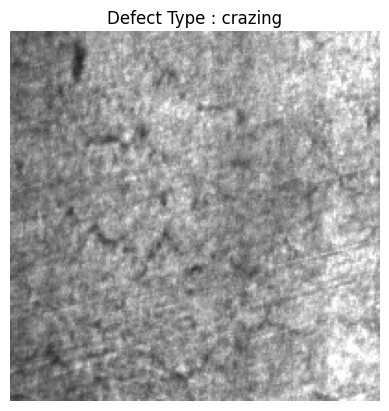

In [14]:
plt.imshow(image_rgb)
plt.title("Defect Type : " + folder_name)
plt.axis("off")
plt.show()

In [13]:
print("Image shape:", image.shape)
print("Top-left pixel value:", image_rgb[0, 0])

Image shape: (200, 200, 3)
Top-left pixel value: [120 120 120]


In [15]:
class_folders = os.listdir(DATA_PATH)
print("Classes:", class_folders)

Classes: ['inclusion', 'rolled-in_scale', 'pitted_surface', 'crazing', 'patches', 'scratches']


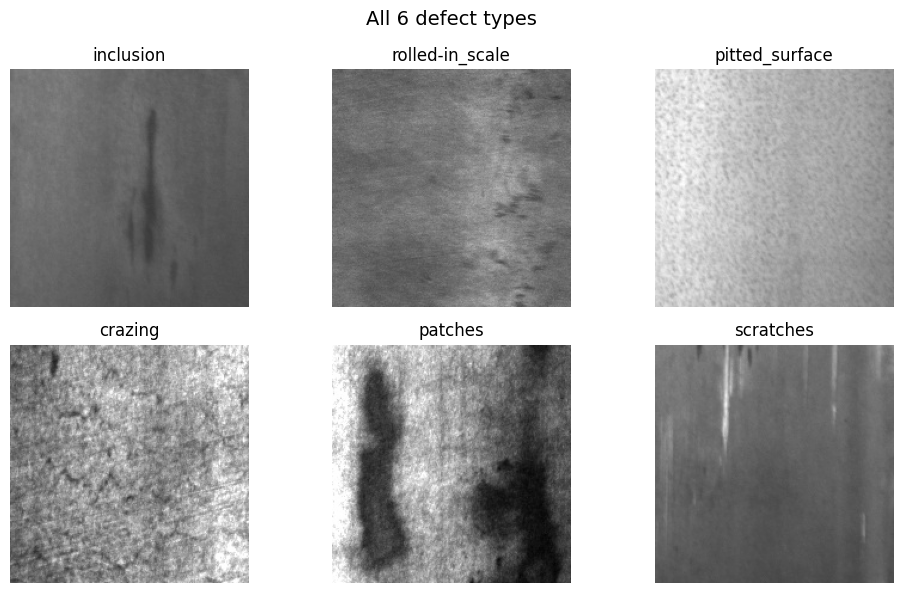

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()
for i, class_name in enumerate(class_folders):
  class_path = os.path.join(DATA_PATH, class_name)
  images_in_folder = os.listdir(class_path)
  img_path = os.path.join(class_path, images_in_folder[0])
  img = cv2.imread(img_path)
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  axes[i].imshow(img_rgb)
  axes[i].set_title(class_name)
  axes[i].axis("off")
plt.suptitle("All 6 defect types", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
for class_name in class_folders:
    class_path = os.path.join(DATA_PATH, class_name)
    count = len(os.listdir(class_path))
    print(f"{class_name} --> {count} images")

inclusion --> 240 images
rolled-in_scale --> 240 images
pitted_surface --> 240 images
crazing --> 240 images
patches --> 240 images
scratches --> 240 images


In [23]:
hist_r = cv2.calcHist([image], [2], None, [32], [0, 256])
hist_g = cv2.calcHist([image], [1], None, [32], [0, 256])
hist_b = cv2.calcHist([image], [0], None, [32], [0, 256])
print("Histogram shape for one channel:", hist_r.shape)

Histogram shape for one channel: (32, 1)


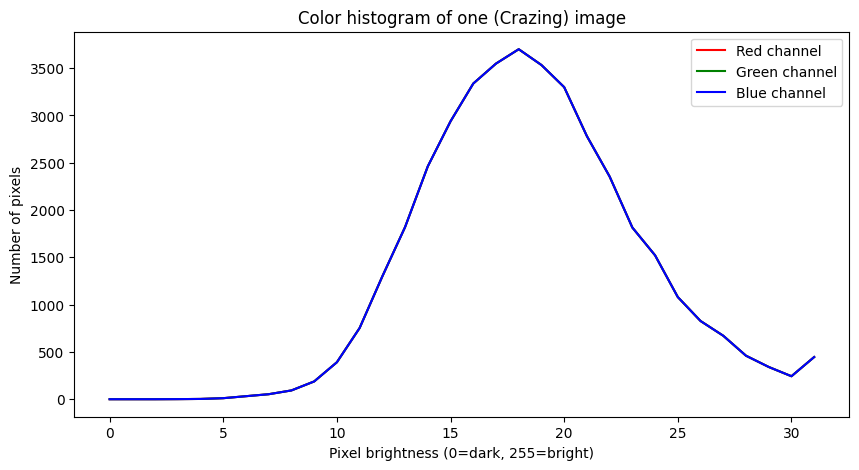

In [26]:
plt.figure(figsize=(10,5))
plt.plot(hist_r, color='red',   label='Red channel')
plt.plot(hist_g, color='green', label='Green channel')
plt.plot(hist_b, color='blue',  label='Blue channel')
plt.title("Color histogram of one (Crazing) image")
plt.xlabel("Pixel brightness (0=dark, 255=bright)")
plt.ylabel("Number of pixels")
plt.legend()
plt.show()

In [28]:
feature_vector = np.concatenate([hist_r.flatten(),
                                  hist_g.flatten(),
                                  hist_b.flatten()])
print("Feature vector length:", len(feature_vector))
print("First 10 values:", feature_vector[:10])

Feature vector length: 96
First 10 values: [  0.   0.   0.   1.   3.  11.  32.  53.  93. 188.]


In [31]:
all_features = []
all_labels = []
for class_name in class_folders:
    class_path = os.path.join(DATA_PATH, class_name)
    image_files = os.listdir(class_path)

    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        h_r = cv2.calcHist([img], [2], None, [32], [0, 256]).flatten()
        h_g = cv2.calcHist([img], [1], None, [32], [0, 256]).flatten()
        h_b = cv2.calcHist([img], [0], None, [32], [0, 256]).flatten()
        feature = np.concatenate([h_r, h_g, h_b])
        all_features.append(feature)
        all_labels.append(class_name)
    print(f"Done processing: {class_name} — {len(image_files)} images")

print("\nTotal images processed:", len(all_features))
print("Total labels collected:", len(all_labels))

Done processing: inclusion — 240 images
Done processing: rolled-in_scale — 240 images
Done processing: pitted_surface — 240 images
Done processing: crazing — 240 images
Done processing: patches — 240 images
Done processing: scratches — 240 images

Total images processed: 1440
Total labels collected: 1440


In [33]:
X = np.array(all_features)
y = np.array(all_labels)
print("X shape :",X.shape)
print("y shape :",y.shape)
print("Sample Labels :",y[:6])

X shape : (1440, 96)
y shape : (1440,)
Sample Labels : ['inclusion' 'inclusion' 'inclusion' 'inclusion' 'inclusion' 'inclusion']


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Training Samples : 1152
Testing Samples : 288


In [36]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [41]:
y_pred = model.predict(X_test)
print("First 10 actual labels :",y_test[:10])
print("First 10 predicted labels :",y_pred[:10])

First 10 actual labels : ['inclusion' 'pitted_surface' 'pitted_surface' 'inclusion'
 'pitted_surface' 'patches' 'scratches' 'scratches' 'patches'
 'rolled-in_scale']
First 10 predicted labels : ['inclusion' 'pitted_surface' 'pitted_surface' 'inclusion'
 'pitted_surface' 'patches' 'rolled-in_scale' 'scratches' 'patches'
 'rolled-in_scale']


In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :",accuracy)

Accuracy : 0.8819444444444444


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

        crazing       0.90      0.85      0.87        52
      inclusion       0.89      0.98      0.93        42
        patches       0.90      0.96      0.92        45
 pitted_surface       0.86      0.83      0.84        52
rolled-in_scale       0.90      0.90      0.90        49
      scratches       0.85      0.81      0.83        48

       accuracy                           0.88       288
      macro avg       0.88      0.89      0.88       288
   weighted avg       0.88      0.88      0.88       288



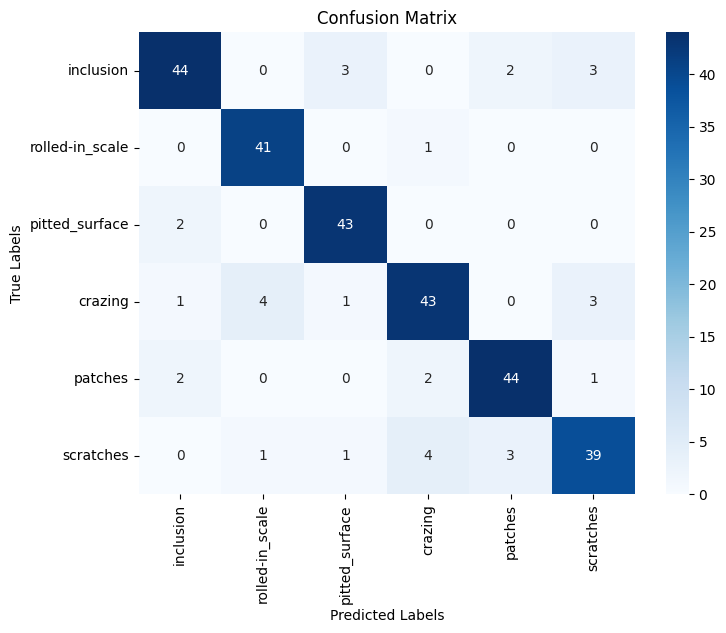

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True,fmt='d',xticklabels=class_folders,yticklabels=class_folders,cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [50]:
from sklearn.preprocessing import normalize
X_normalized = normalize(X)
print("Before :",X[0:3])
print("After :",X_normalized[0:3])

Before : [[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 1.8500e+02 4.9400e+02 2.2110e+03 6.1100e+03 8.5830e+03
  8.8380e+03 7.1600e+03 4.8130e+03 1.5710e+03 3.5000e+01 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 1.8500e+02 4.9400e+02 2.2110e+03
  6.1100e+03 8.5830e+03 8.8380e+03 7.1600e+03 4.8130e+03 1.5710e+03
  3.5000e+01 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.8500e+02
  4.9400e+02 2.2110e+03 6.1100e+03 8.5830e+03 8.8380e+03 7.1600e+03
  4.8130e+03 1.5710e+03 3.5000e+01 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.00

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X_normalized,y,test_size=0.2,random_state=42)

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [58]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [61]:
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy :",rf_accuracy)

Random Forest Accuracy : 0.9479166666666666


In [64]:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train,y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test,dt_pred)

In [65]:
model_score = ['Decision Tree', 'Random Forest']
accuracy_score = [dt_accuracy, rf_accuracy]

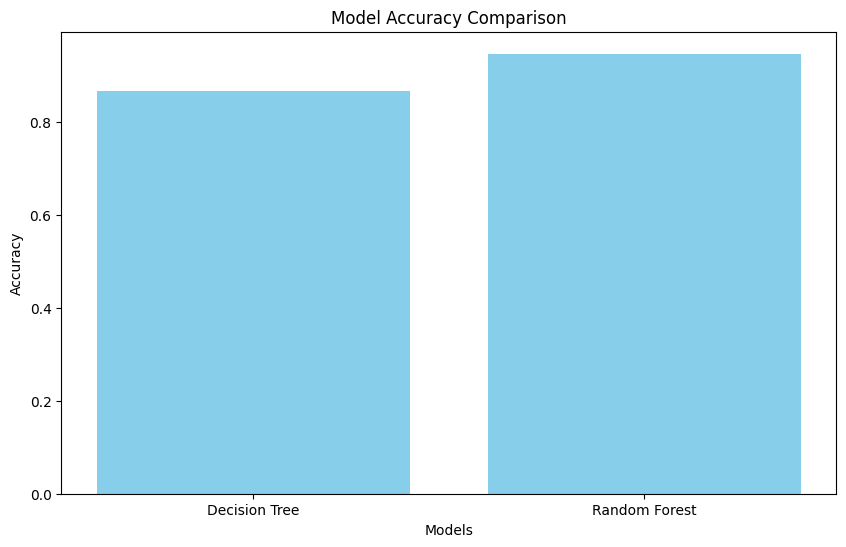

In [66]:
plt.figure(figsize=(10,6))
plt.bar(model_score,accuracy_score,color='skyblue')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

In [69]:
import joblib
joblib.dump(rf_model, 'Paint_Defect_Detection_Model.pkl')

['Paint_Defect_Detection_Model.pkl']

In [70]:
import json
with open('class_names.json','w') as f:
  json.dump(class_folders,f)

In [85]:
loaded_model = joblib.load('Paint_Defect_Detection_Model.pkl')

In [92]:
folder

['inclusion',
 'rolled-in_scale',
 'pitted_surface',
 'crazing',
 'patches',
 'scratches']

In [93]:
test_class = 'pitted_surface'

In [94]:
test_folder = os.path.join(DATA_PATH, test_class)
test_image_path = os.path.join(test_folder,os.listdir(test_folder)[5])

In [95]:
test_img = cv2.imread(test_image_path)
h_r = cv2.calcHist([test_img], [2], None, [32], [0, 256]).flatten()
h_g = cv2.calcHist([test_img], [1], None, [32], [0, 256]).flatten()
h_b = cv2.calcHist([test_img], [0], None, [32], [0, 256]).flatten()
test_feature = np.concatenate([h_r, h_g, h_b]).reshape(1, -1)

In [96]:
test_feature_norm = normalize(test_feature)
prediction = loaded_model.predict(test_feature_norm)
print(f"Actual class   :",test_class)
print(f"Predicted class :",prediction[0])

Actual class   : pitted_surface
Predicted class : pitted_surface


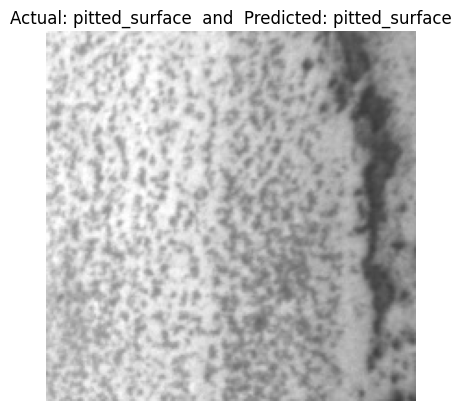

In [97]:
test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
plt.imshow(test_img_rgb)
plt.title(f"Actual: {test_class}  and  Predicted: {prediction[0]}")
plt.axis("off")
plt.show()